# LOADING THE LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# LOADING THE DATASET

In [2]:
df = pd.read_csv('hotel_bookings.csv')

In [3]:
df.head(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


# UNDERSTANDING THE DATA

In [14]:
print('Number of Rows in the dataset:', df.shape[0],'\n')
print('Number of Columns in the dataset:' , df.shape[1],'\n')
print('Description about dataset:')
df.info()

Number of Rows in the dataset: 119390 

Number of Columns in the dataset: 32 

Description about dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        11

# DATA TYPE ANALYSIS

In [19]:
df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

In [22]:
# change a date column stored as object into datetime
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

In [20]:
# float columns which are not normal
improper_cols = ['children' , 'agent' ,'company']

In [21]:
for i in improper_cols:
    u = df[i].unique()
    print(i)
    print(u)

children
[ 0.  1.  2. 10.  3. nan]
agent
[ nan 304. 240. 303.  15. 241.   8. 250. 115.   5. 175. 134. 156. 243.
 242.   3. 105.  40. 147. 306. 184.  96.   2. 127.  95. 146.   9. 177.
   6. 143. 244. 149. 167. 300. 171. 305.  67. 196. 152. 142. 261. 104.
  36.  26.  29. 258. 110.  71. 181.  88. 251. 275.  69. 248. 208. 256.
 314. 126. 281. 273. 253. 185. 330. 334. 328. 326. 321. 324. 313.  38.
 155.  68. 335. 308. 332.  94. 348. 310. 339. 375.  66. 327. 387. 298.
  91. 245. 385. 257. 393. 168. 405. 249. 315.  75. 128. 307.  11. 436.
   1. 201. 183. 223. 368. 336. 291. 464. 411. 481.  10. 154. 468. 410.
 390. 440. 495. 492. 493. 434.  57. 531. 420. 483. 526. 472. 429.  16.
 446.  34.  78. 139. 252. 270.  47. 114. 301. 193. 182. 135. 350. 195.
 352. 355. 159. 363. 384. 360. 331. 367.  64. 406. 163. 414. 333. 427.
 431. 430. 426. 438. 433. 418. 441. 282. 432.  72. 450. 180. 454. 455.
  59. 451. 254. 358. 469. 165. 467. 510. 337. 476. 502. 527. 479. 508.
 535. 302. 497. 187.  13.   7.  27. 

In [29]:
for i in improper_cols:
    try:
        
        df[i] = df[i].astype('int64')
    except Exception as e:
        print(f"Something went wrong: {e}")

Something went wrong: Cannot convert non-finite values (NA or inf) to integer
Something went wrong: Cannot convert non-finite values (NA or inf) to integer
Something went wrong: Cannot convert non-finite values (NA or inf) to integer


In [30]:
# coverting it into 'Int64' instead of 'int64'
for i in improper_cols:
    try:
        
        df[i] = df[i].astype('Int64')
    except Exception as e:
        print(f"Something went wrong: {e}")

In [68]:
df.dtypes

hotel                                     object
is_canceled                                int64
lead_time                                  int64
arrival_date_year                          int64
arrival_date_month                        object
arrival_date_week_number                   int64
arrival_date_day_of_month                  int64
stays_in_weekend_nights                    int64
stays_in_week_nights                       int64
adults                                     int64
children                                   Int64
babies                                     int64
meal                                      object
country                                   object
market_segment                            object
distribution_channel                      object
is_repeated_guest                          int64
previous_cancellations                     int64
previous_bookings_not_canceled             int64
reserved_room_type                        object
assigned_room_type  

# NULL ANALYSIS

In [32]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [33]:
# 1st column - children 
df['children'] = df['children'].fillna(df['children'].median())

In [44]:
# 2nd column - country
df['country'] = df['country'].fillna(df['country'].mode()[0])

In [45]:
df['agent'] = df['agent'].fillna(df['agent'].median())

In [46]:
# for company column....there are lot of nulls compared to the rows count..
# so simply drop that column
df.drop(columns = ['company'] , inplace = True)

In [49]:
#final check
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces 

# DUPLICATE ANALYSIS

In [50]:
df.duplicated().sum()

32020

In [51]:
#
duplicate_pairs = df[df.duplicated(keep=False)]

In [52]:
duplicate_pairs.head()


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,240,0,Transient,98.00,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,240,0,Transient,98.00,0,1,Check-Out,2015-07-03
21,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,1,No Deposit,250,0,Transient,84.67,0,1,Check-Out,2015-07-07
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,1,No Deposit,250,0,Transient,84.67,0,1,Check-Out,2015-07-07
39,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,0,No Deposit,250,0,Transient,137.00,0,1,Check-Out,2015-07-07


In [53]:
#The dataset contains 31,994 duplicate rows.
#Since there is no unique booking identifier available, it is not possible to determine whether these rows represent
#duplicate records or separate hotel bookings with identical characteristics.

#hence to avoid the removing of data (which is not knowm to be true duplicates) i have keep the duplicates


In [59]:
pd.set_option('display.max_columns', None)
df.head(1)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,14,0,Transient,0.0,0,0,Check-Out,2015-07-01


# OUTLIERS ANALYSIS

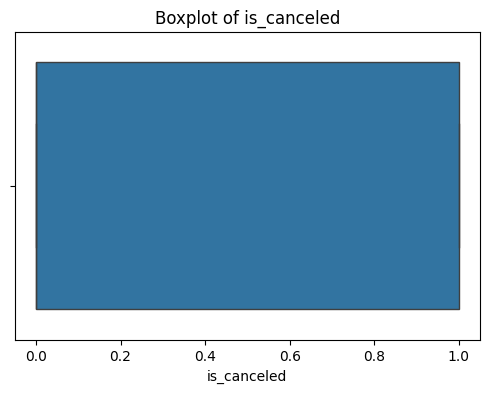

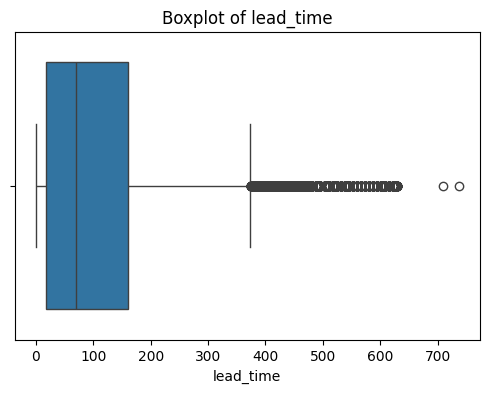

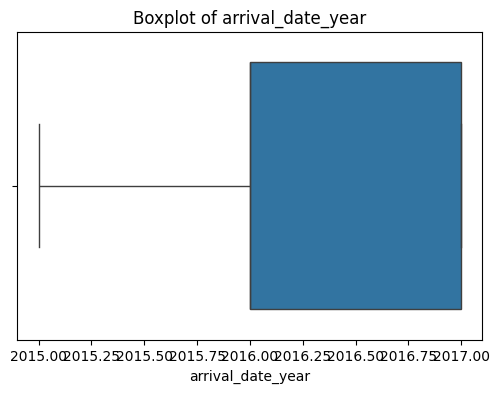

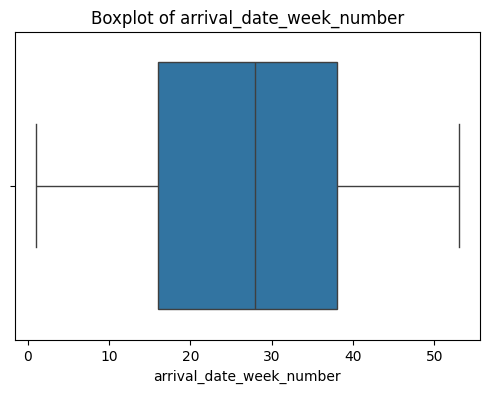

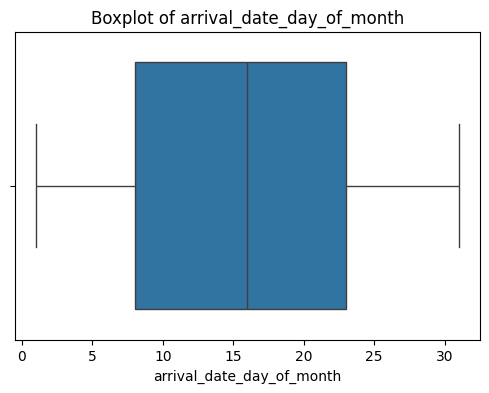

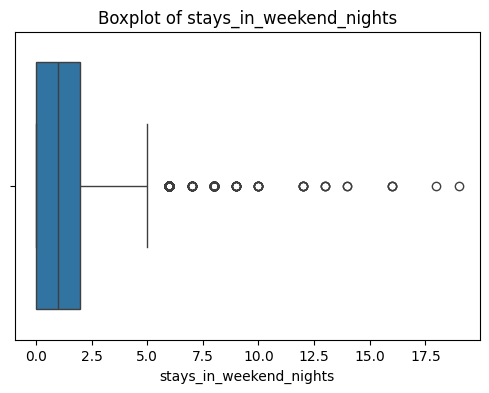

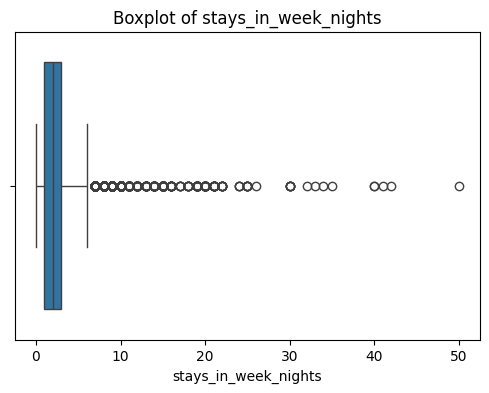

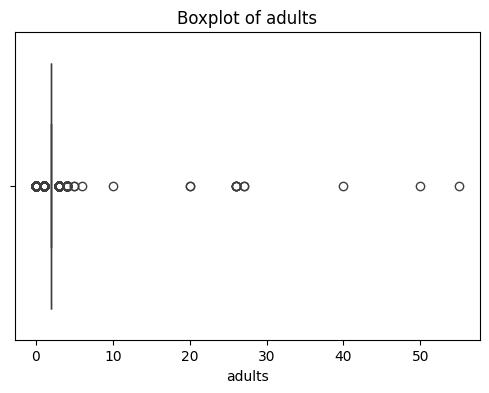

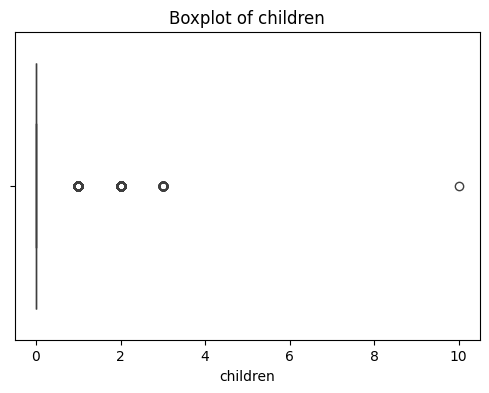

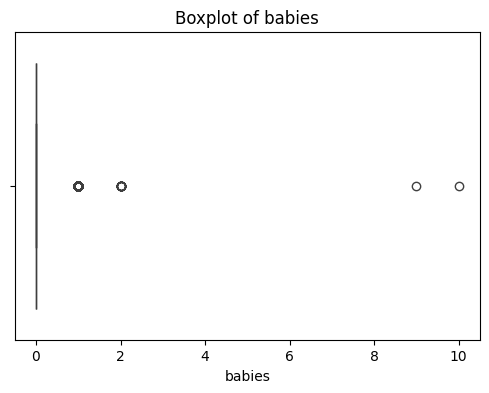

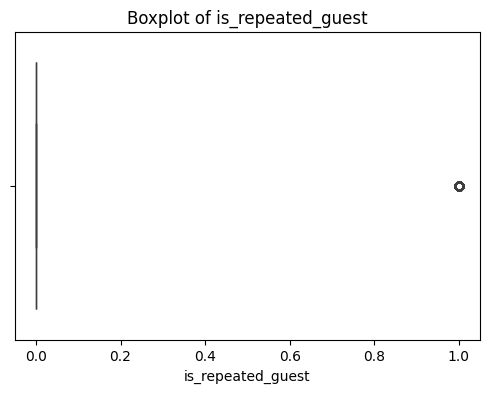

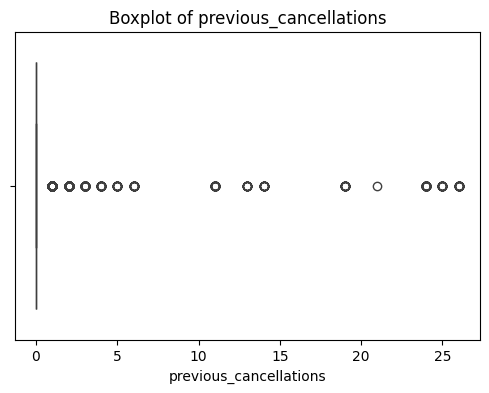

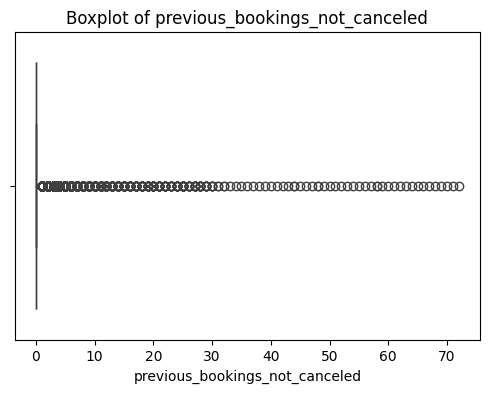

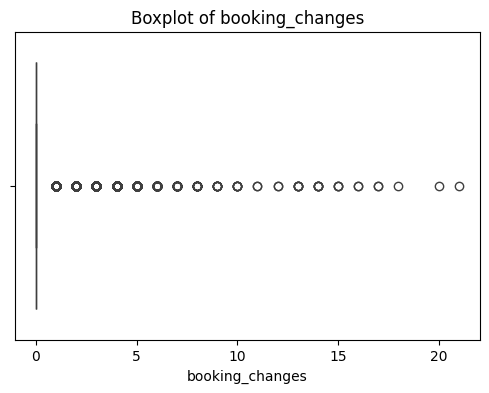

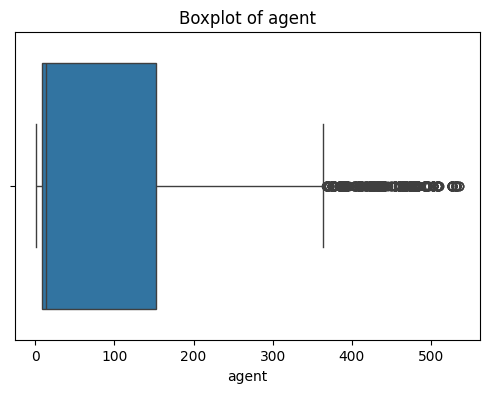

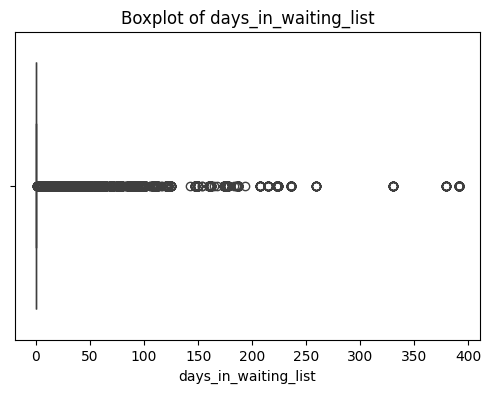

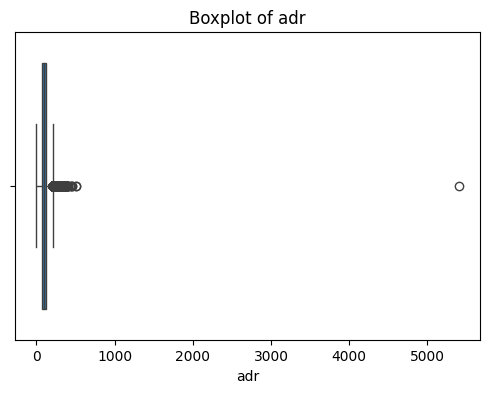

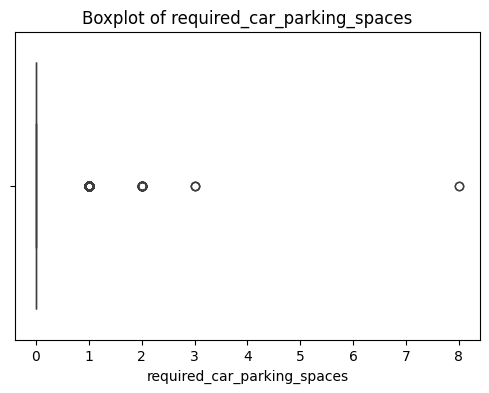

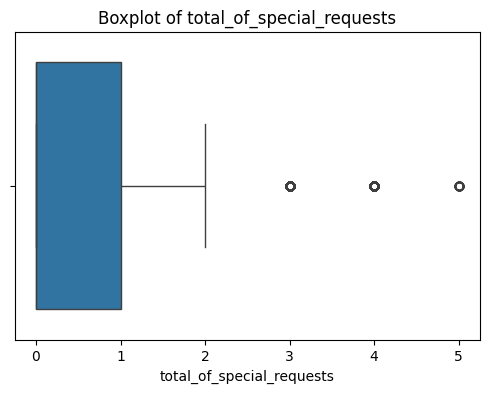

In [110]:
for i in df.select_dtypes(include = 'number').columns:
    plt.figure(figsize=(6,4))

    sns.boxplot(x = df[i])
    plt.title(f'Boxplot of {i}')
    plt.show()

In [123]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
is_canceled,119390.0,0.370416,0.0,0.0,0.0,1.0,1.0,0.482918
lead_time,119390.0,104.011416,0.0,18.0,69.0,160.0,737.0,106.863097
arrival_date_year,119390.0,2016.156554,2015.0,2016.0,2016.0,2017.0,2017.0,0.707476
arrival_date_week_number,119390.0,27.165173,1.0,16.0,28.0,38.0,53.0,13.605138
arrival_date_day_of_month,119390.0,15.798241,1.0,8.0,16.0,23.0,31.0,8.780829
stays_in_weekend_nights,119390.0,0.927599,0.0,0.0,1.0,2.0,19.0,0.998613
stays_in_week_nights,119390.0,2.500302,0.0,1.0,2.0,3.0,50.0,1.908286
adults,119390.0,1.856403,0.0,2.0,2.0,2.0,55.0,0.579261
children,119390.0,0.103886,0.0,0.0,0.0,0.0,10.0,0.398555
babies,119390.0,0.007949,0.0,0.0,0.0,0.0,10.0,0.097436


In [165]:
df[df['adr'] < 0]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
14969,Resort Hotel,0,195,2017,March,10,5,4,6,2,0,0,BB,GBR,Groups,Direct,1,0,2,A,H,2,No Deposit,273,0,Transient-Party,-6.38,0,0,Check-Out,2017-03-15


In [166]:
df = df[df['adr'] >= 0]

In [167]:
#check again
df[df['adr'] < 0]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date


# VISUALISATIONS

# Lead Time Distribution and ADR Distribution


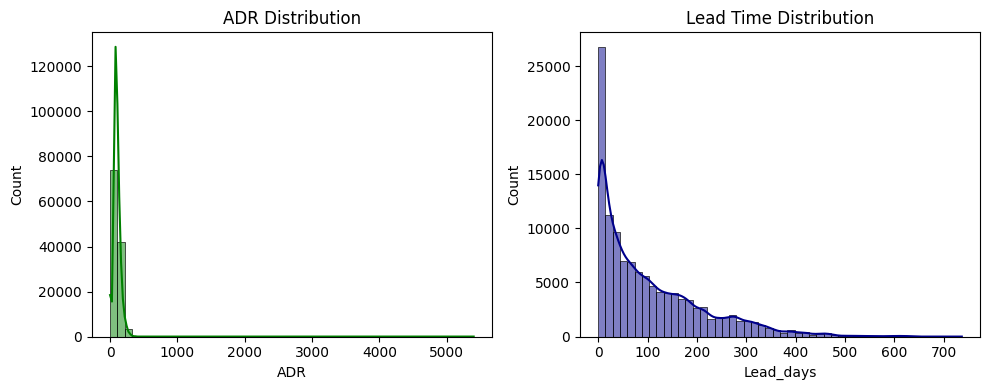

In [207]:
fig , ax = plt.subplots(1,2,figsize = (10,4))

sns.histplot(df['adr'],
            bins = 50,
            kde = True,
            color = 'green',
            ax=ax[0])


sns.histplot(df['lead_time'],
            bins = 50,
            kde = True,
            color = 'darkblue',
            ax=ax[1])

ax[0].set_title('ADR Distribution')
ax[0].set_xlabel('ADR')
ax[0].set_ylabel('Count')

ax[1].set_title('Lead Time Distribution')
ax[1].set_xlabel('Lead_days')
ax[1].set_ylabel('Count')


plt.tight_layout()
plt.show()

# Hotel Type Distribution

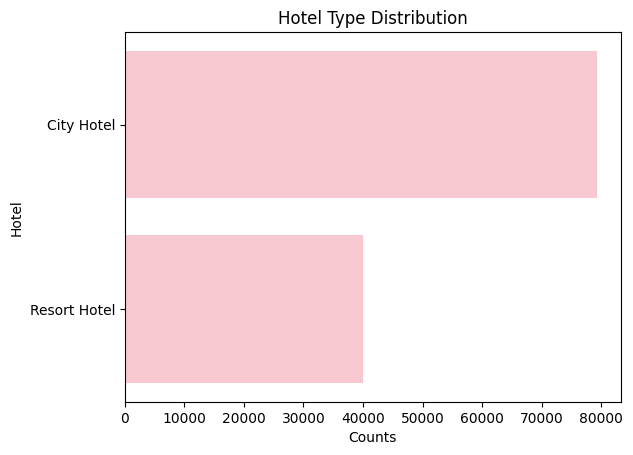

In [582]:
sns.countplot(data = df,
              y = 'hotel',
              color = 'pink',
              order = df['hotel'].value_counts().index)

plt.title('Hotel Type Distribution')
plt.xlabel('Counts')
plt.ylabel('Hotel')
plt.show()

# Market Segment Share

In [221]:
df['market_segment'].nunique()

8

In [259]:
market_seg = df['market_segment'].value_counts().reset_index()

market_seg.columns = ['values' , 'counts']
print(market_seg)

          values  counts
0      Online TA   56477
1  Offline TA/TO   24219
2         Groups   19810
3         Direct   12606
4      Corporate    5295
5  Complementary     743
6       Aviation     237
7      Undefined       2


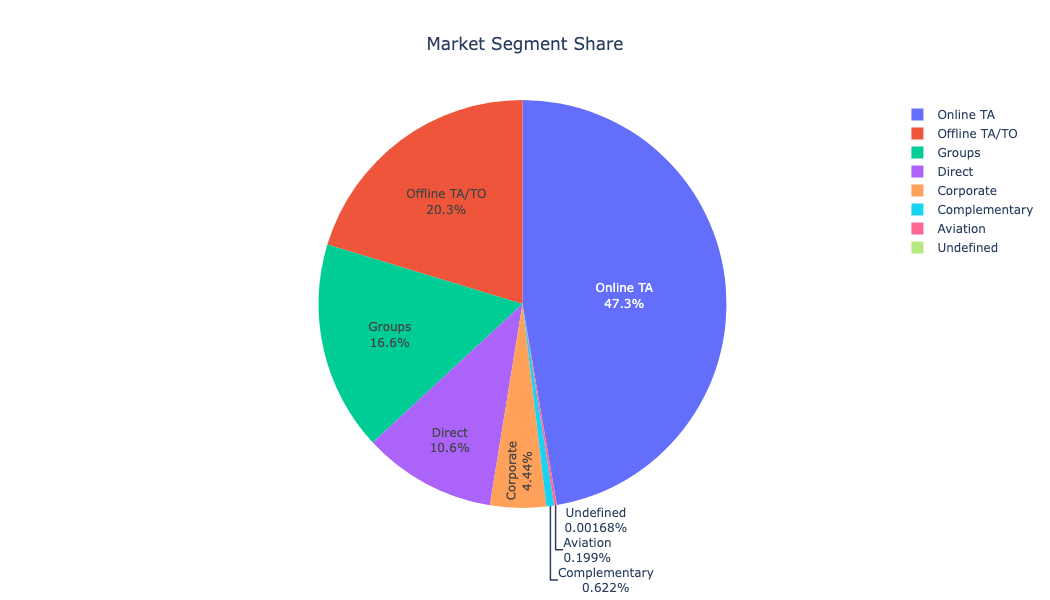

In [260]:
import plotly.express as px

fig = px.pie(market_seg,
             names = 'values',
             values = 'counts',
             title = 'Market Segment Share'
            )

fig.update_layout(
    width=600,
    height=600
)


fig.update_traces(
    textinfo='percent+label'
)

fig.update_layout(
    title_x=0.5
)

    
fig.show()

# Customer Insights: Top Booking Countries

In [272]:
country_sum = df['country'].value_counts().head(10).reset_index()
country_sum

,country,count
0,PRT,49078
1,GBR,12128
2,FRA,10415
3,ESP,8568
4,DEU,7287
5,ITA,3766
6,IRL,3375
7,BEL,2342
8,BRA,2224
9,NLD,2104


In [273]:
country_sum.columns

Index(['country', 'count'], dtype='object')

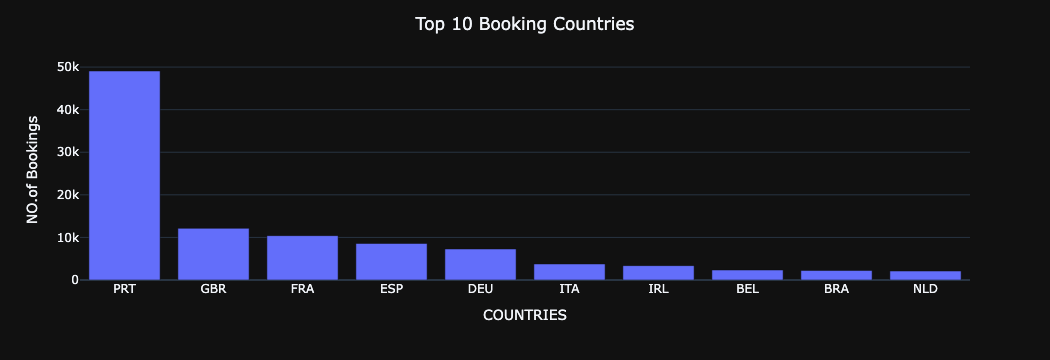

In [301]:
fig = px.bar(country_sum,
             x = 'country',
             y = 'count'
             )


fig.update_layout(
    title = 'Top 10 Booking Countries',
    title_x= 0.5,
    xaxis_title = 'COUNTRIES',
    yaxis_title = 'NO.of Bookings'
)

fig.update_layout(
    template='plotly_dark'
)


fig.show()

# Average and Total Group Size by Country

In [303]:
df.head(1)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,14,0,Transient,0.0,0,0,Check-Out,2015-07-01


In [306]:
#feature engineering
#create a new col: group size

df['group_size'] = df['adults'] + df['babies'] + df['children']
df['group_size'].head()

0    2
1    2
2    1
3    1
4    2
Name: group_size, dtype: Int64

In [314]:
avg_grp_size_country = (df.groupby('country')['group_size'].mean().sort_values(ascending=False)
      .head(10)
)

In [315]:
avg_grp_size_country

country
AIA    4.0
DJI    4.0
FJI    4.0
COM    3.5
TMP    3.0
ZMB    3.0
MYT    3.0
FRO    3.0
GLP    3.0
NIC    3.0
Name: group_size, dtype: Float64

In [325]:
total_grp_size_country = (df.groupby('country')['group_size'].sum().sort_values(ascending=False).
                         head(10))

In [326]:
total_grp_size_country 

country
PRT    90721
GBR    24566
FRA    21579
ESP    18153
DEU    14198
ITA     7856
IRL     6909
BEL     4911
BRA     4867
USA     4318
Name: group_size, dtype: Int64

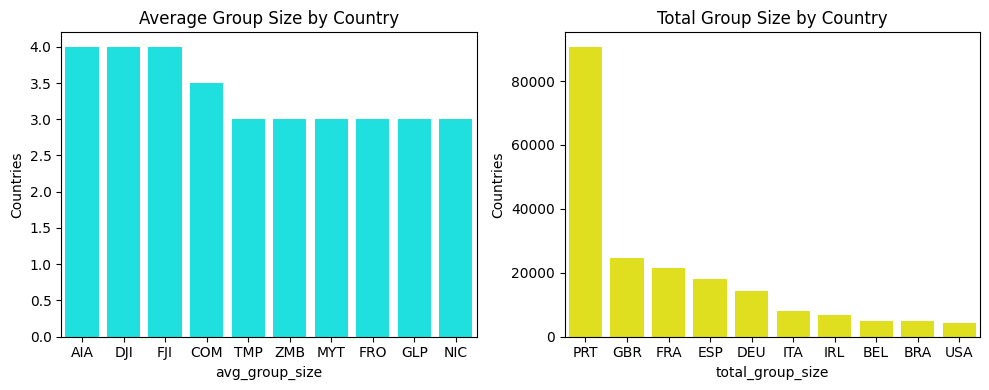

In [342]:
fig , ax = plt.subplots(1,2, figsize=(10,4))

sns.barplot(x = avg_grp_size_country.index,
           y = avg_grp_size_country.values,
           color = 'aqua',
           ax= ax[0])

sns.barplot(x = total_grp_size_country.index,
           y = total_grp_size_country.values,
           color = 'yellow', 
           ax= ax[1])

ax[0].set_title('Average Group Size by Country')
ax[0].set_xlabel('avg_group_size')
ax[0].set_ylabel('Countries')

ax[1].set_title('Total Group Size by Country')
ax[1].set_xlabel('total_group_size')
ax[1].set_ylabel('Countries')


plt.tight_layout()
plt.show()


# Cancellation Analysis : Cancellation Percentage

In [356]:
# per of cancelled

In [345]:
cancel_per = df['is_canceled'].sum()/ len(df) * 100

In [346]:
cancel_per

37.04193853705115

In [ ]:
# per of not cancelled

In [354]:
not_cancel_per = ((df['is_canceled'] == 0).sum()/ len(df)) * 100

In [355]:
not_cancel_per

62.95806146294885

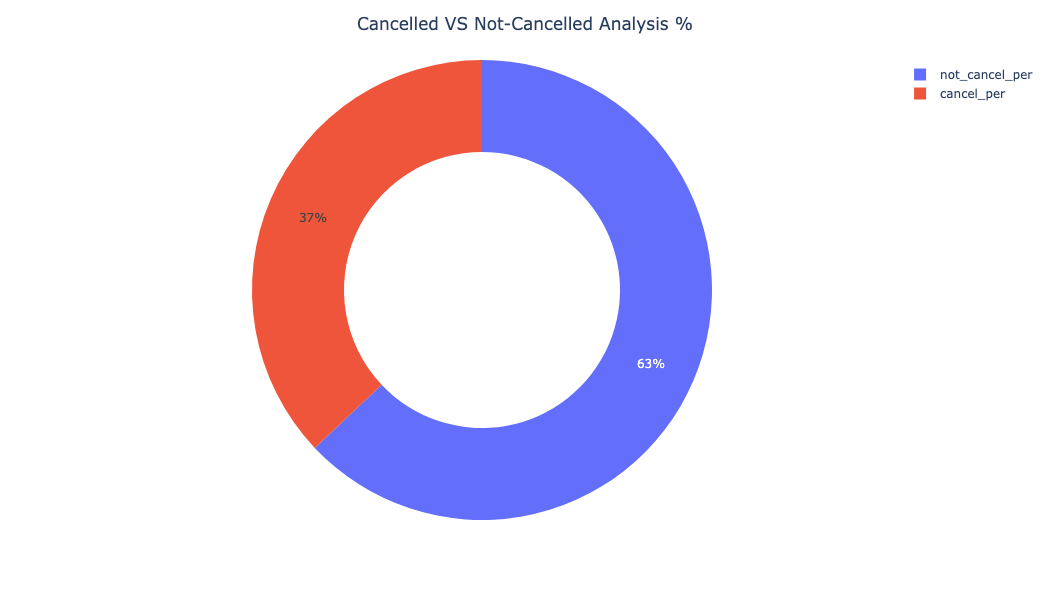

In [372]:
fig = px.pie(
    names = ['cancel_per' ,'not_cancel_per'],
    values =[cancel_per, not_cancel_per],
    hole = 0.6
)

fig.update_layout(
    title = 'Cancelled VS Not-Cancelled Analysis %',
    title_x = 0.5
)

fig.update_layout(
    width=600,
    height=600
)



fig.show()

# Hotel Type vs Cancellation and Percentage ,Lead Time vs Cancellation

In [378]:
cancel_hotel_type = df.groupby('hotel')['is_canceled'].mean()*100

In [379]:
cancel_hotel_type

hotel
City Hotel      41.726963
Resort Hotel    27.764048
Name: is_canceled, dtype: float64

In [401]:
print(cancel_hotel_type.index)
print(cancel_hotel_type.values)

Index(['City Hotel', 'Resort Hotel'], dtype='object', name='hotel')
[41.72696332 27.76404803]


In [414]:
cancelled_df = df[df['is_canceled'] == 1]

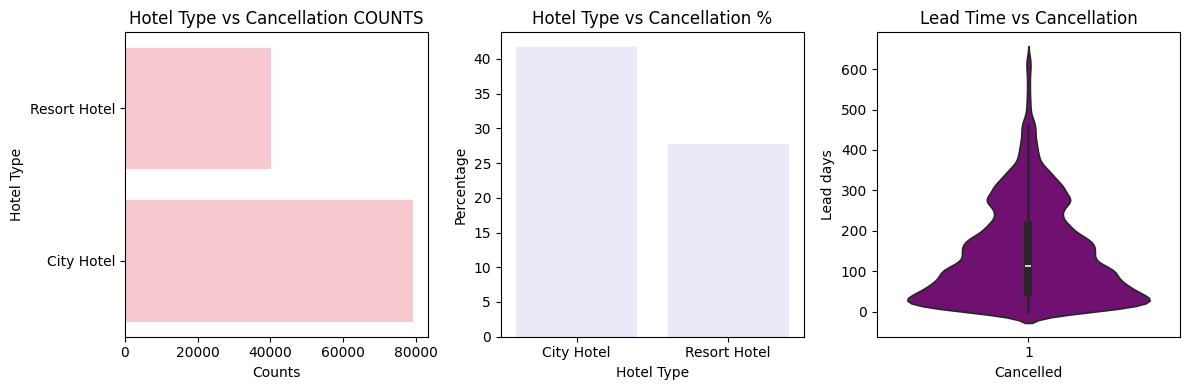

In [581]:
fig , ax = plt.subplots(1,3 , figsize = (12,4))

sns.countplot(
    df,
    y = 'hotel',
    color = 'pink',
    ax=ax[0]
)

sns.barplot(
    x = cancel_hotel_type.index,
    y = cancel_hotel_type.values,
    color = 'lavender',
    ax=ax[1]
)

sns.violinplot(
    cancelled_df,
    x='is_canceled',
    y='lead_time',
    color = 'purple',
    ax=ax[2]
)


ax[0].set_title('Hotel Type vs Cancellation COUNTS')
ax[0].set_xlabel('Counts')
ax[0].set_ylabel('Hotel Type')


ax[1].set_title('Hotel Type vs Cancellation %')
ax[1].set_xlabel('Hotel Type')
ax[1].set_ylabel('Percentage')

ax[2].set_title('Lead Time vs Cancellation')
ax[2].set_xlabel('Cancelled')
ax[2].set_ylabel('Lead days')


plt.tight_layout()
plt.show()

# Revenue by Hotel

In [442]:
# first creating the revenue col using the ard info

df['revenue'] = (df['adr'] * (df['stays_in_weekend_nights'] + df['stays_in_week_nights']))

In [453]:
hotel_revenue = (df.groupby('hotel')['revenue'].sum().reset_index())

In [454]:
hotel_revenue

,hotel,revenue
0,City Hotel,25279469.96
1,Resort Hotel,17444091.37


In [455]:
hotel_revenue.columns

Index(['hotel', 'revenue'], dtype='object')

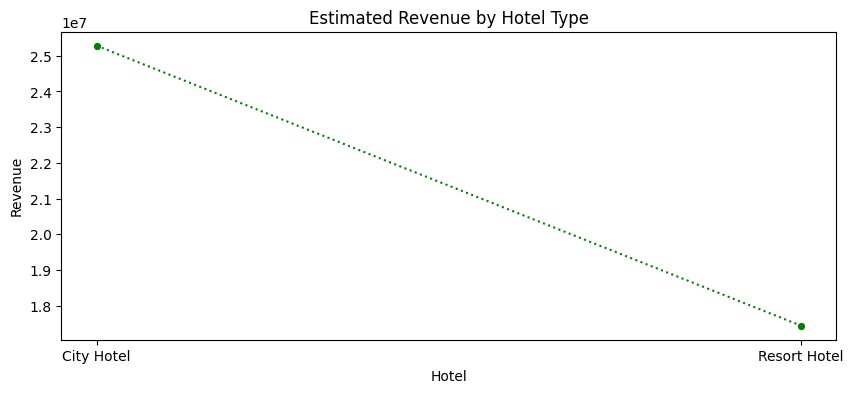

In [466]:
plt.figure(figsize = (10,4))

sns.lineplot(
    data = hotel_revenue,
    x = 'hotel',
    y = 'revenue',
    color = 'green',
    linestyle = ':',
    marker = 'o'
)

plt.title('Estimated Revenue by Hotel Type')
plt.xlabel('Hotel')
plt.ylabel('Revenue')

plt.show()

# Monthly Revenue Trend

In [467]:
# monthly revenue Trend

month_rev = (df.groupby('arrival_date_month')['revenue'].sum().reset_index())

In [472]:
month_rev = month_rev.sort_values(by="revenue", ascending=False)
month_rev

,arrival_date_month,revenue
1,August,7944717.43
5,July,6587713.64
6,June,4499387.28
8,May,4108125.90
11,September,3731917.18
0,April,3710466.14
10,October,3009549.50
7,March,2639284.89
3,February,1818972.70
2,December,1800192.70


In [512]:
# sorting accoring to actual Montly pattern

month_order = [
    'January','February','March',
    'April','May','June',
    'July','August','September',
    'October','November','December'
]

month_rev['arrival_date_month'] = pd.Categorical(
    month_rev['arrival_date_month'],
    categories=month_order,
    ordered=True
)

month_rev =month_rev.sort_values(
    'arrival_date_month'
)

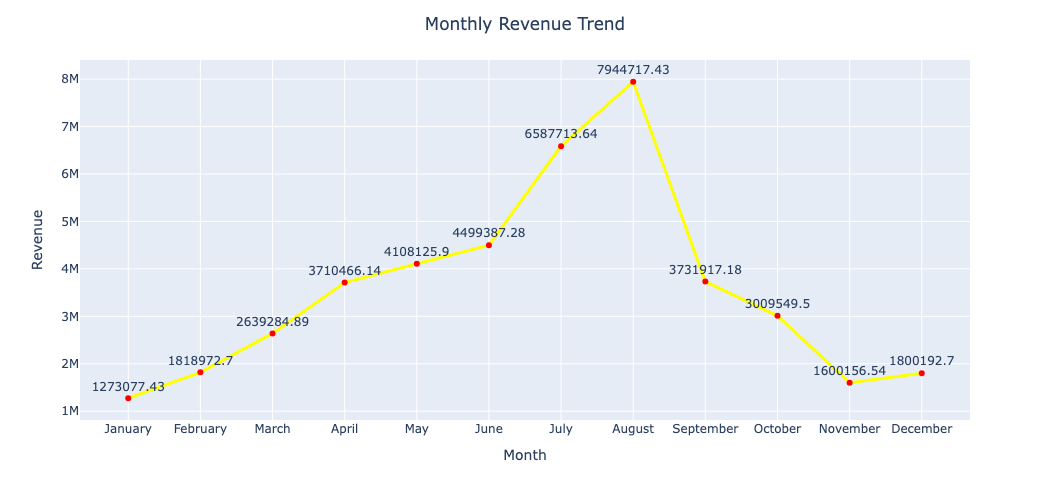

In [511]:
fig = px.line(
    month_rev,
    x = 'arrival_date_month',
    y = 'revenue',
    text='revenue',
    markers=True
    
)

fig.update_layout(
    title = 'Monthly Revenue Trend',
    title_x = 0.5,
    xaxis_title = 'Month',
    yaxis_title = 'Revenue',
    width=1100,
    height=500
    
)

fig.update_traces(
    line_color='yellow',
    line_width= 3,
    marker_color = 'red',
    textposition='top center'
    
)

fig.show()

# Monthly Revenue Trend by Hotel

In [515]:
month_rev_hotel = (df.groupby(['arrival_date_month' , 'hotel'])['revenue'].sum().reset_index())

In [522]:
# sorting accoring to actual Montly pattern

month_rev_hotel['arrival_date_month'] = pd.Categorical(
    month_rev_hotel['arrival_date_month'],
    categories=month_order,
    ordered=True
)

month_rev_hotel =month_rev_hotel.sort_values(
    'arrival_date_month'
)


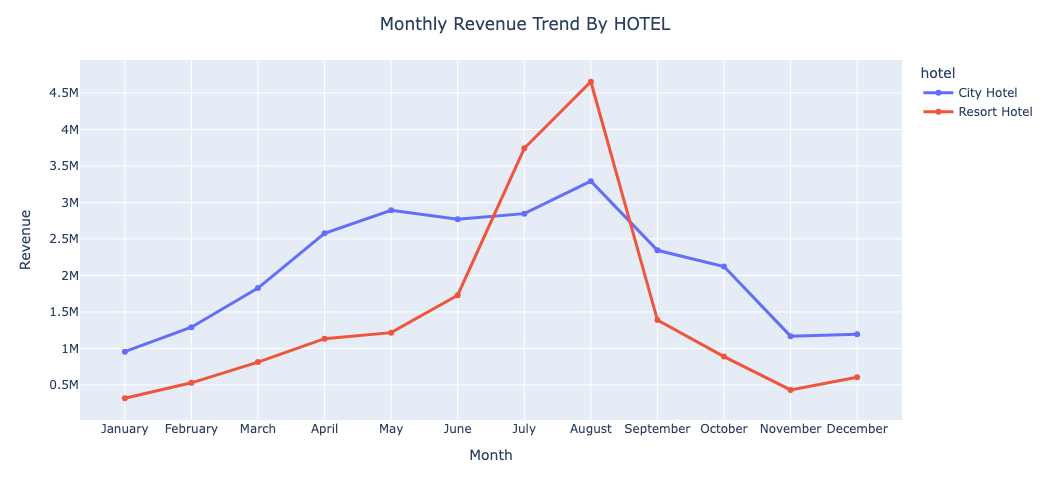

In [525]:

fig = px.line(
    month_rev_hotel,
    x = 'arrival_date_month',
    y = 'revenue',
    color='hotel',
    markers=True
    
)

fig.update_layout(
    title = 'Monthly Revenue Trend By HOTEL',
    title_x = 0.5,
    xaxis_title = 'Month',
    yaxis_title = 'Revenue',
    width=1100,
    height=500
    
)

fig.update_traces(
    line_width= 3,
    
    
)

fig.show()

# Correlation Analysis 

In [532]:
corr = df.corr(numeric_only=True)

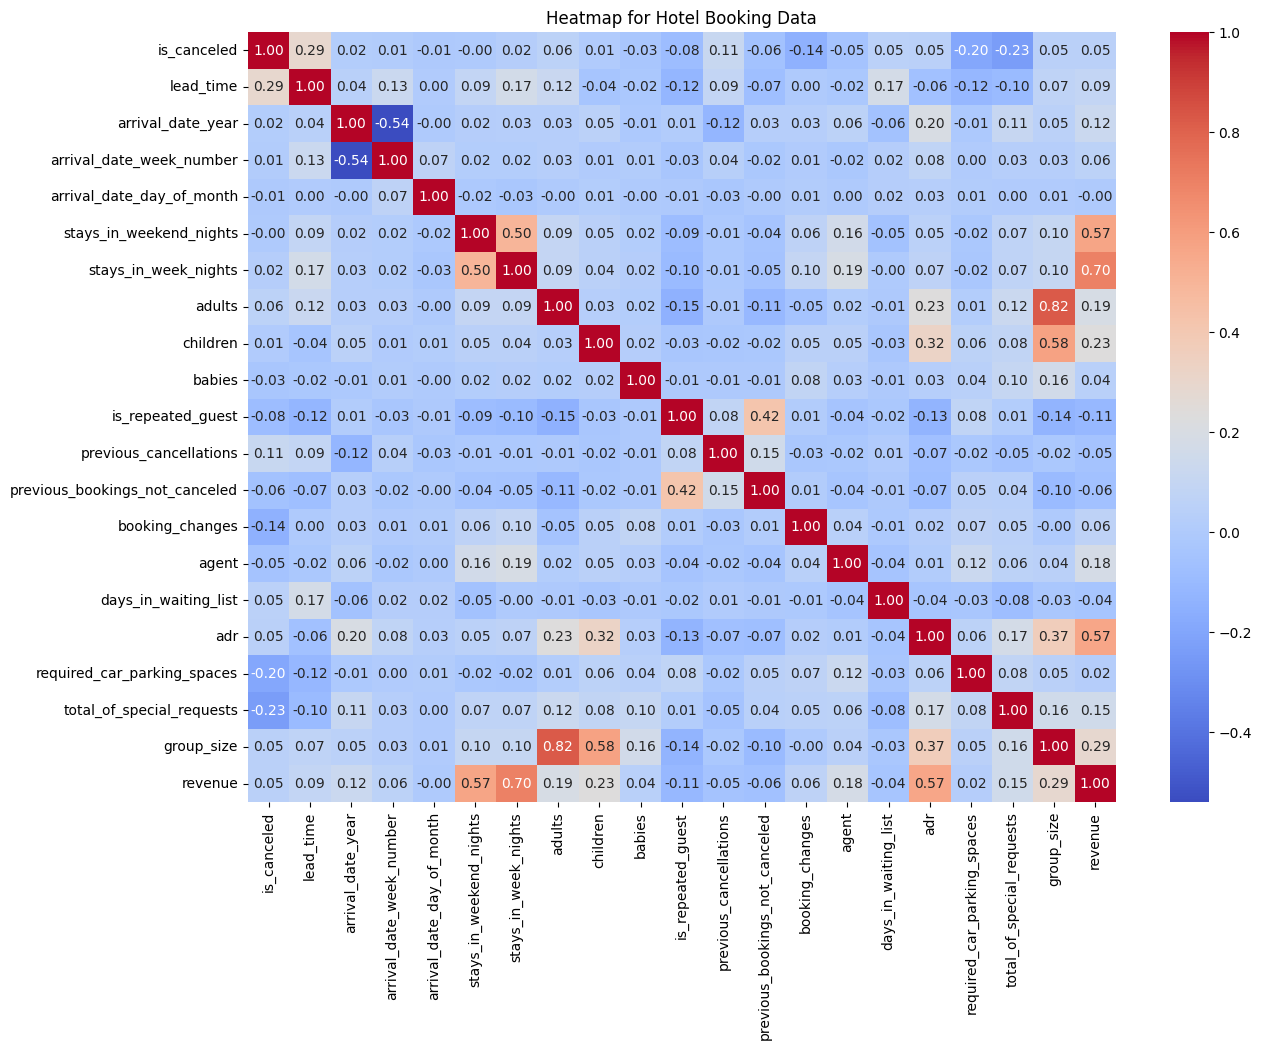

In [583]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Heatmap for Hotel Booking Data')


plt.show()

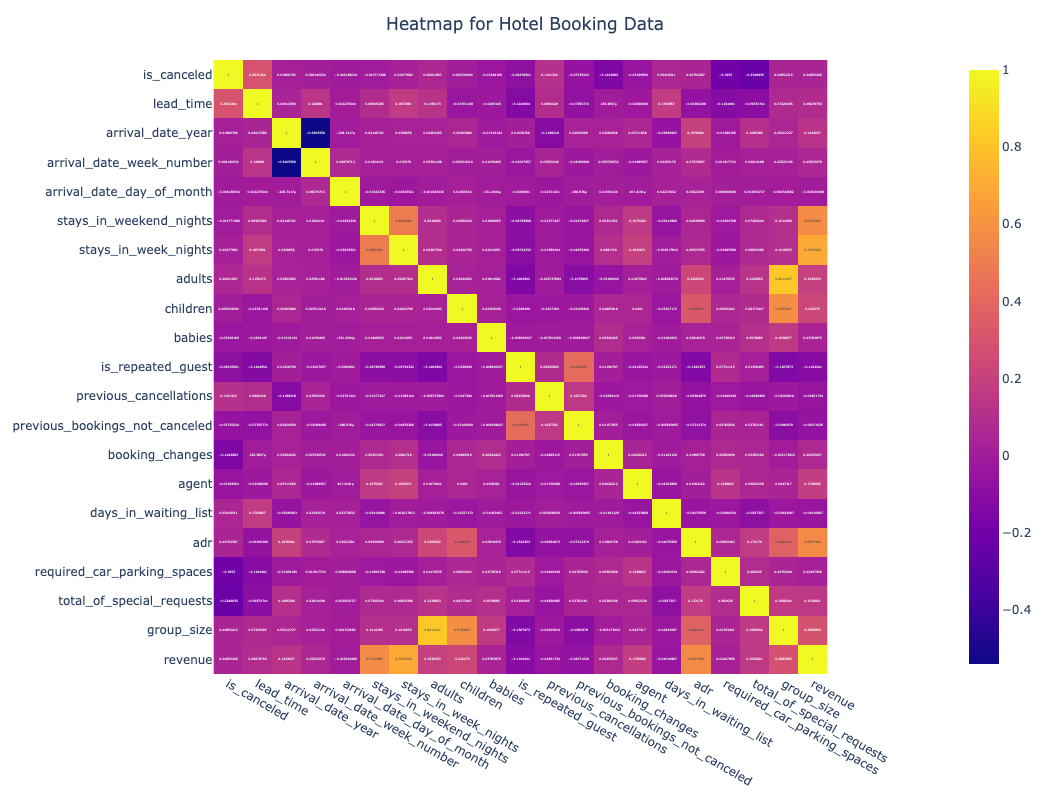

In [588]:
# correlation using Plotly as well
fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale='Plasma'
)

fig.update_layout(
    title = 'Heatmap for Hotel Booking Data',
    title_x = 0.5,
    width = 1000,
    height = 800
)

fig.show()

# ADR vs Group Size by Hotel

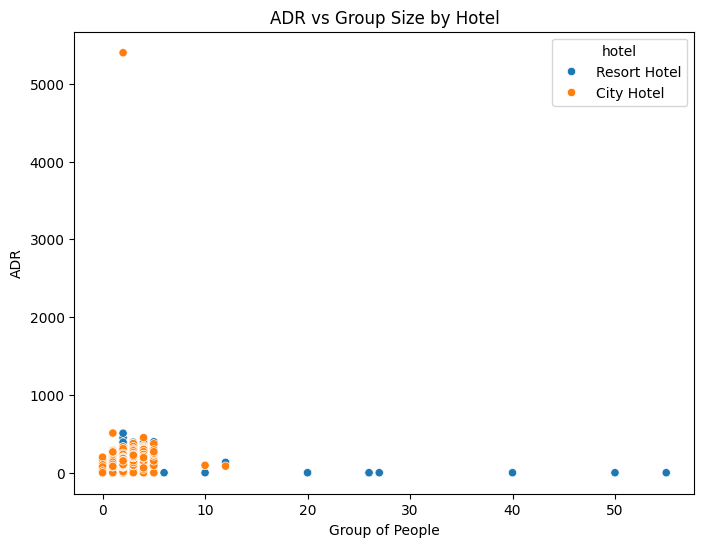

In [575]:
plt.figure(figsize = (8,6))

sns.scatterplot(
    df,
    x='group_size',
    y='adr',
    hue='hotel'
)

plt.title('ADR vs Group Size by Hotel')
plt.xlabel('Group of People')
plt.ylabel('ADR')

plt.show()

# Reservation Status Distribution

In [576]:
#creating status_counts 

status_counts = (
    df['reservation_status']
    .value_counts()
    .reset_index()
)

status_counts.columns = [
    'reservation_status',
    'count']

status_counts

,reservation_status,count
0,Check-Out,75165
1,Canceled,43017
2,No-Show,1207


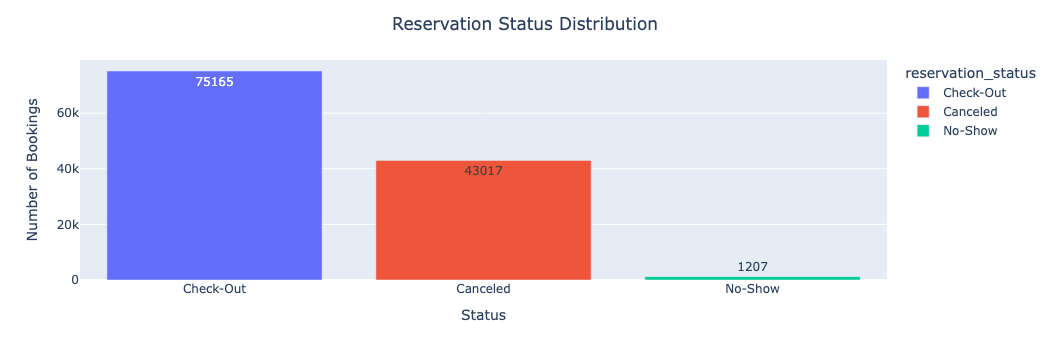

In [577]:
fig = px.bar(
    status_counts,
    x='reservation_status',
    y='count',
    color='reservation_status',
    text='count'
)

fig.update_layout(
    title='Reservation Status Distribution',
    title_x = 0.5,
    xaxis_title='Status',
    yaxis_title='Number of Bookings'
)

fig.show()